# Loan Eligibility Analysis

## Tentang Dataset

Dataset berikut digunakan untuk memprediksi apakah calon peminjam memenuhi syarat untuk disetujui peminjamannya berdasarkan wilayah, keuangan, dan faktor yang berhubungan dengan kredit lainnta. Dataset ini cocok untuk klasifikasi menggunakan machine learning.

Dataset diperoleh dari repository Kaggle pada link berikut

https://www.kaggle.com/datasets/avineshprabhakaran/loan-eligibility-prediction

Dataset memiliki cakupan data sebagai berikut

|Column|Description|Example|
|--|--|--|
|Customer_ID| Unique identifier for each loan applicant	|569|
|Gender|Gender of the applicant	|Male / Female|
|Married	|Marital status of the applicant |Yes / No
|Dependents	|Number of dependents	|0, 1, 2, 3
|Education	|Education level of the applicant	|Graduate / Not Graduate
|Self_Employed	|Whether the applicant is self-employed	|Yes / No
|Applicant_Income	|Applicant’s monthly income	|5000
|Coapplicant_Income	|Coapplicant’s monthly income	|1500
|Loan_Amount	|Loan amount requested (in thousands)	|128
|Loan_Amount_Term	|Loan repayment term (in months)	|360
|Credit_History	|Credit history meets lending criteria |(1 = Yes, 0 = No)	1
|Property_Area	|Type of property area | Urban / Semiurban / Rural
|Loan_Status	|Loan approved or not (target variable)	|Y / N

## Import the library

In [119]:
import kagglehub
import os

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import matplotlib as mpl
import seaborn as sns

## Download the dataset

In [121]:
path = kagglehub.dataset_download("avineshprabhakaran/loan-eligibility-prediction")
filename = os.listdir(path)[0]

fullpath = "/".join([path,filename])
fullpath

Using Colab cache for faster access to the 'loan-eligibility-prediction' dataset.


'/kaggle/input/loan-eligibility-prediction/Loan Eligibility Prediction.csv'

## Set the default plot style

In [138]:
def DefaultPlotStyle():
  plt.rcParams['lines.linewidth'] = 2
  plt.rcParams['lines.linestyle'] = '-'
  plt.rcParams['figure.figsize'] = [12,10]
  plt.rcParams['font.size'] = 12

DefaultPlotStyle()

## Read the dataset

In [122]:
df = pd.read_csv(fullpath)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         614 non-null    int64  
 1   Gender              614 non-null    object 
 2   Married             614 non-null    object 
 3   Dependents          614 non-null    int64  
 4   Education           614 non-null    object 
 5   Self_Employed       614 non-null    object 
 6   Applicant_Income    614 non-null    int64  
 7   Coapplicant_Income  614 non-null    float64
 8   Loan_Amount         614 non-null    int64  
 9   Loan_Amount_Term    614 non-null    int64  
 10  Credit_History      614 non-null    int64  
 11  Property_Area       614 non-null    object 
 12  Loan_Status         614 non-null    object 
dtypes: float64(1), int64(6), object(6)
memory usage: 62.5+ KB


## Dataset Checking

In [124]:
# Checking missing value
df.isnull().sum().reset_index().T

,0,1,2,3,4,5,6,7,8,9,10,11,12
index,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,0,0,0,0,0,0,0,0,0,0,0,0


There is missing or empty valu in this dataset

In [125]:
# Checking duplicate data
any(df.duplicated())

False

There is no duplicate data in this dataset

In [126]:
# Checking duplicate customer id
df['Customer_ID'].value_counts().reset_index().sort_values(by='count', ascending=False).head()

,Customer_ID,count
613,271,1
0,606,1
1,569,1
2,15,1
3,95,1


There is no duplicate on customer id in this dataset

## Dataset Highlight

In [84]:
df.head()

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,569,Female,No,0,Graduate,No,2378,0.0,9,360,1,Urban,N
1,15,Male,Yes,2,Graduate,No,1299,1086.0,17,120,1,Urban,Y
2,95,Male,No,0,Not Graduate,No,3620,0.0,25,120,1,Semiurban,Y
3,134,Male,Yes,0,Graduate,Yes,3459,0.0,25,120,1,Semiurban,Y
4,556,Male,Yes,1,Graduate,No,5468,1032.0,26,360,1,Semiurban,Y


## Features Analysis

In [127]:
# Creating object feature for Credit History
mapper = lambda x : "YES" if x == 1 else "NO"
df['Credit_History_Obj'] = df['Credit_History'].map(mapper)
df.head()

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Credit_History_Obj
0,569,Female,No,0,Graduate,No,2378,0.0,9,360,1,Urban,N,YES
1,15,Male,Yes,2,Graduate,No,1299,1086.0,17,120,1,Urban,Y,YES
2,95,Male,No,0,Not Graduate,No,3620,0.0,25,120,1,Semiurban,Y,YES
3,134,Male,Yes,0,Graduate,Yes,3459,0.0,25,120,1,Semiurban,Y,YES
4,556,Male,Yes,1,Graduate,No,5468,1032.0,26,360,1,Semiurban,Y,YES


In [128]:
# Selecting only object features
object_list = df.select_dtypes(include=['object']).columns
object_list

Index(['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area',
       'Loan_Status', 'Credit_History_Obj'],
      dtype='object')

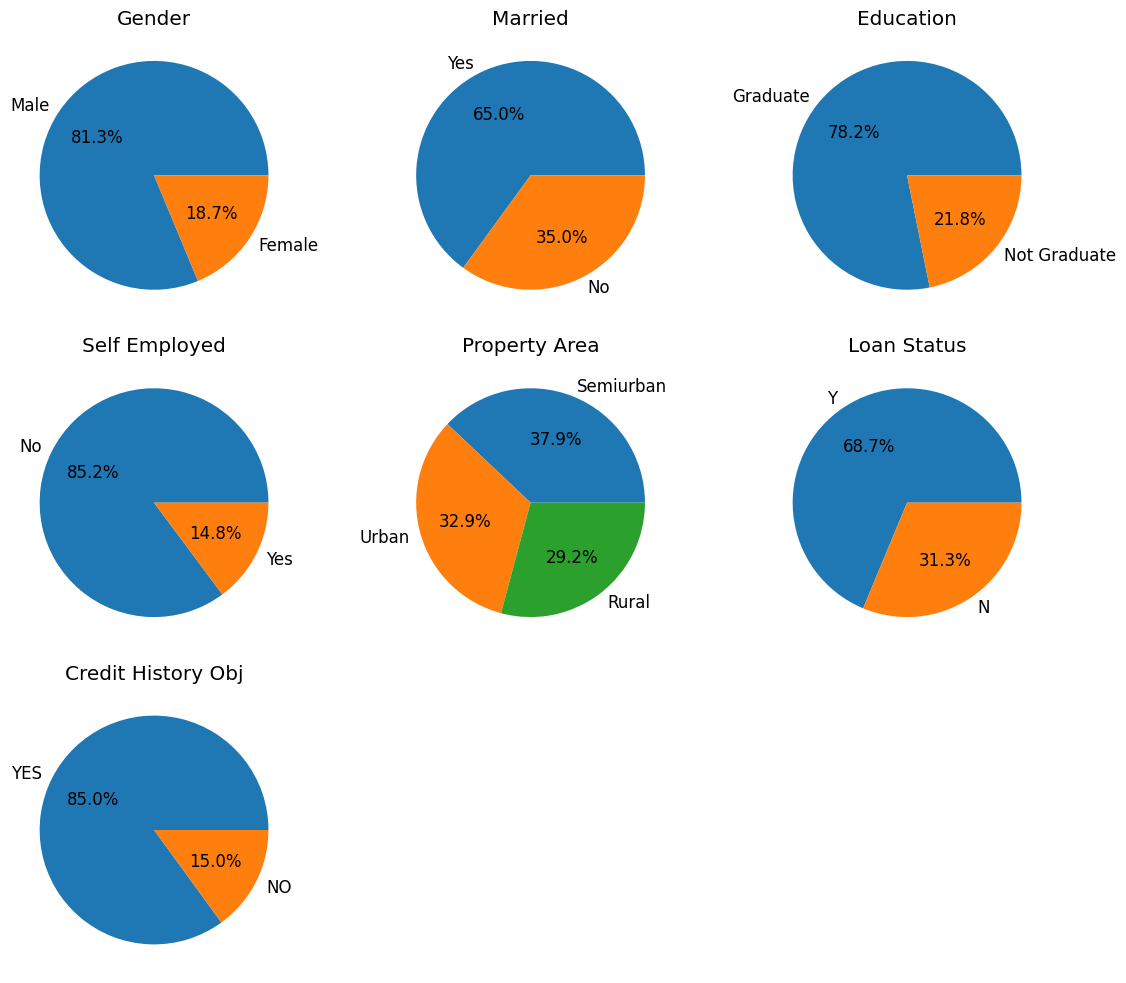

In [139]:
# Plotting object features
ndata = df.shape[0]
nobject = len(object_list)
n_cols = 3
n_rows = (nobject // n_cols) + 1

fig, ax = plt.subplots(nrows=n_rows, ncols=n_cols)
ax_flat = ax.flatten()

for i, ax in enumerate(ax_flat):
  if i < nobject:
    df_obj = df[object_list[i]].value_counts().reset_index()
    df_obj['percentage'] = (df_obj['count']/df_obj['count'].sum()) * 100
    ax = ax_flat[i]
    ax.pie(df_obj['percentage'], labels=df_obj[object_list[i]], autopct="%.1f%%")
    ax.set_title(object_list[i].replace("_", " "))
  else:
    ax.axis('off')

plt.tight_layout()

In [140]:
# Calculating the total income from the applicant income and co-applicant income
df['Total_Income'] = df['Applicant_Income'] + df['Coapplicant_Income']
df.head()

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Credit_History_Obj,Total_Income
0,569,Female,No,0,Graduate,No,2378,0.0,9,360,1,Urban,N,YES,2378.0
1,15,Male,Yes,2,Graduate,No,1299,1086.0,17,120,1,Urban,Y,YES,2385.0
2,95,Male,No,0,Not Graduate,No,3620,0.0,25,120,1,Semiurban,Y,YES,3620.0
3,134,Male,Yes,0,Graduate,Yes,3459,0.0,25,120,1,Semiurban,Y,YES,3459.0
4,556,Male,Yes,1,Graduate,No,5468,1032.0,26,360,1,Semiurban,Y,YES,6500.0


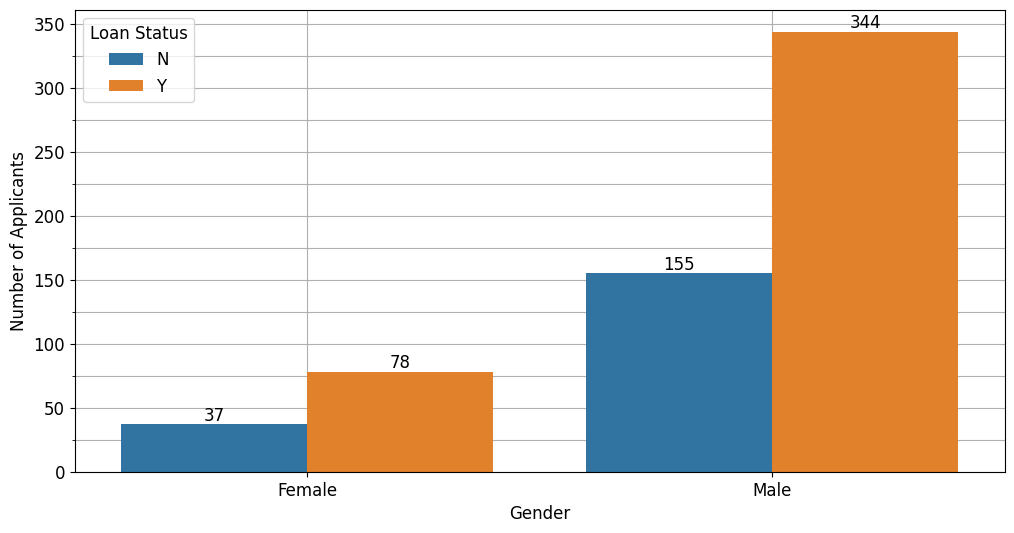

In [150]:
fig, ax = plt.subplots(figsize=(12,6))
sns.countplot(data=df, x='Gender', hue='Loan_Status', ax=ax)
for container in ax.containers:
  ax.bar_label(container, label_type='edge')
# ax.set_ylim([0,200])
ax.set_ylabel('Number of Applicants')
ax.yaxis.set_minor_locator(MultipleLocator(25))
plt.grid(which='both')
plt.legend(title='Loan Status')
ax.set_axisbelow(True)

The most acceptable loan application status is from the Male than Females based on the mean loan amount. However, the Female is a more acceptable loan status than the non-acceptable loan.

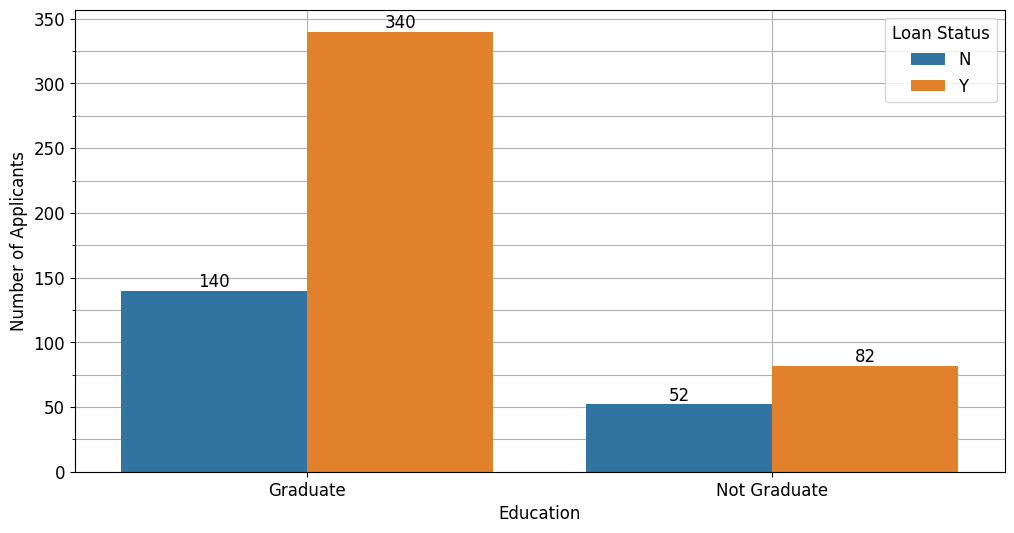

In [153]:
fig, ax = plt.subplots(figsize=(12,6))
sns.countplot(data=df, x='Education',hue='Loan_Status', ax=ax)
for container in ax.containers:
  ax.bar_label(container, label_type='edge')
# ax.set_ylim([0,200])
ax.set_ylabel('Number of Applicants')
ax.yaxis.set_minor_locator(MultipleLocator(25))
plt.grid(which='both')
plt.legend(title='Loan Status')
ax.set_axisbelow(True)

The most applicant acceptable loan status have graduated from the education.

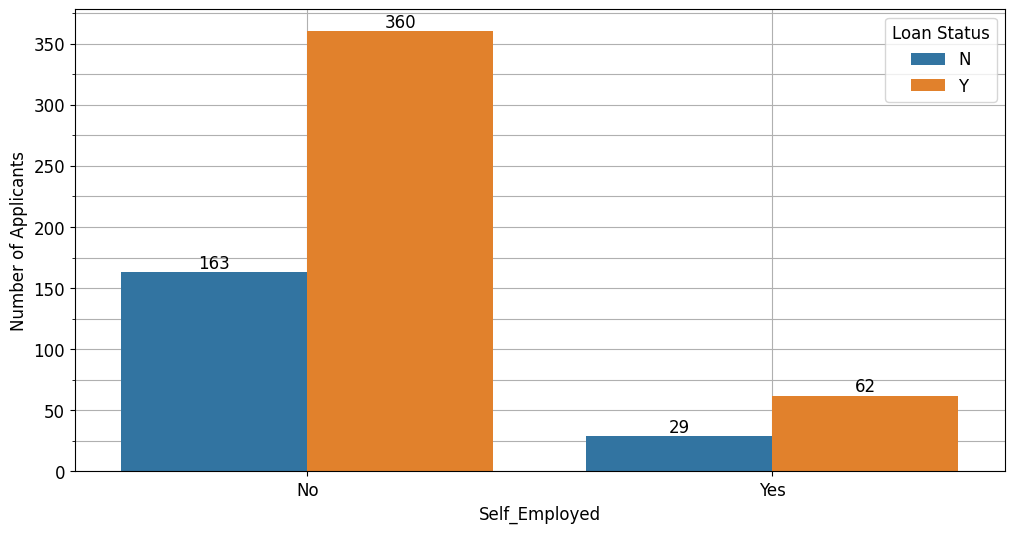

In [154]:
fig, ax = plt.subplots(figsize=(12,6))
sns.countplot(data=df, x='Self_Employed', hue='Loan_Status', ax=ax)
for container in ax.containers:
  ax.bar_label(container, label_type='edge')
# ax.set_ylim([0,200])
ax.set_ylabel('Number of Applicants')
ax.yaxis.set_minor_locator(MultipleLocator(25))
plt.grid(which='both')
plt.legend(title='Loan Status')
ax.set_axisbelow(True)

The most applicants who get the acceptable loan status unemployed applicants.

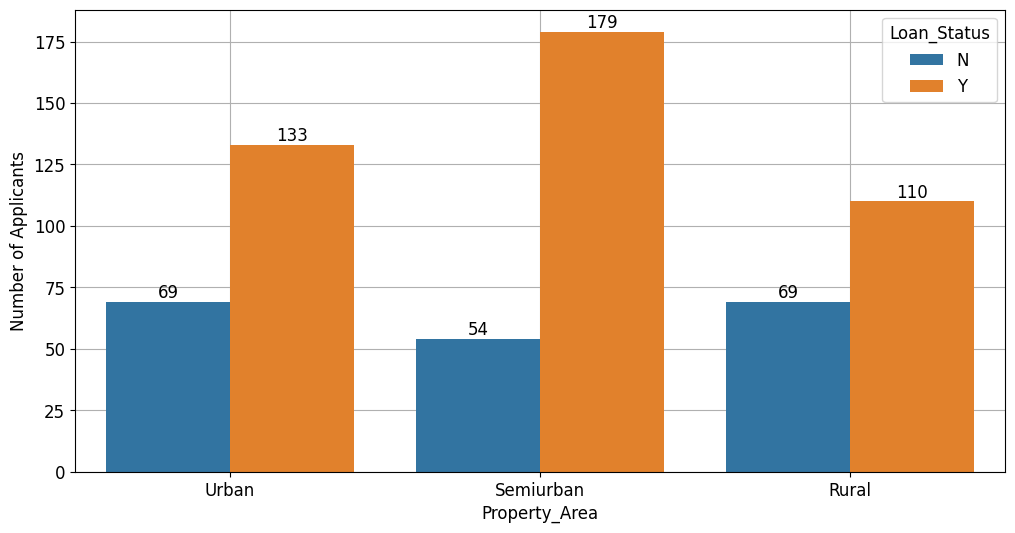

In [157]:
fig, ax = plt.subplots(figsize=(12,6))
sns.countplot(data=df, x='Property_Area', hue='Loan_Status', ax=ax)
for container in ax.containers:
  ax.bar_label(container, label_type='edge')
# ax.set_ylim([0,200])
ax.set_ylabel('Number of Applicants')
ax.yaxis.set_minor_locator(MultipleLocator(25))
plt.grid(which='both')
ax.set_axisbelow(True)

The applicants who are living in the semiurban area are the most acceptable loan status, following the urban and rural area.

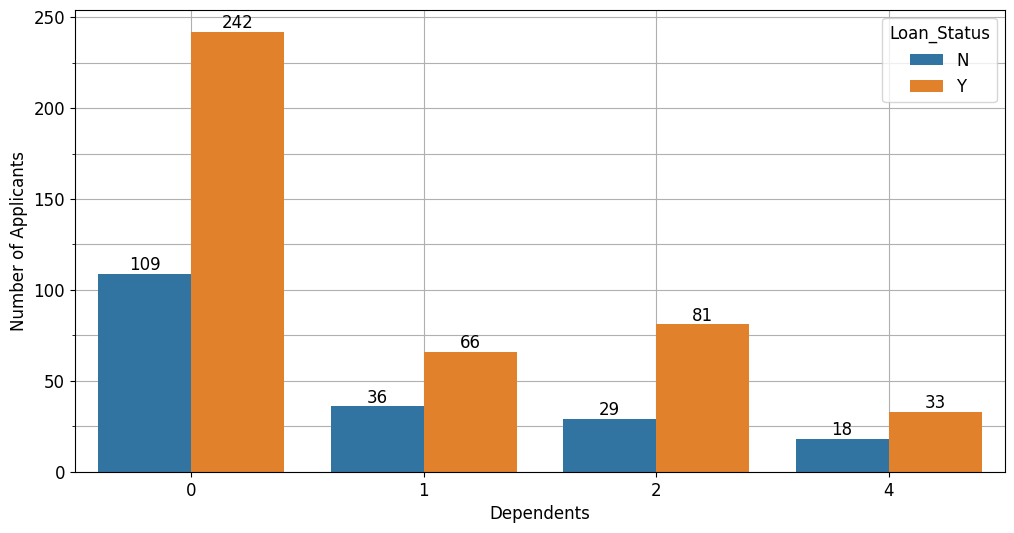

In [158]:
fig, ax = plt.subplots(figsize=(12,6))
sns.countplot(data=df, x='Dependents', hue='Loan_Status', ax=ax)
for container in ax.containers:
  ax.bar_label(container, label_type='edge')
# ax.set_ylim([0,200])
ax.set_ylabel('Number of Applicants')
ax.yaxis.set_minor_locator(MultipleLocator(25))
plt.grid(which='both')
ax.set_axisbelow(True)

The applicants who don not have a dependent are the most acceptable loan status

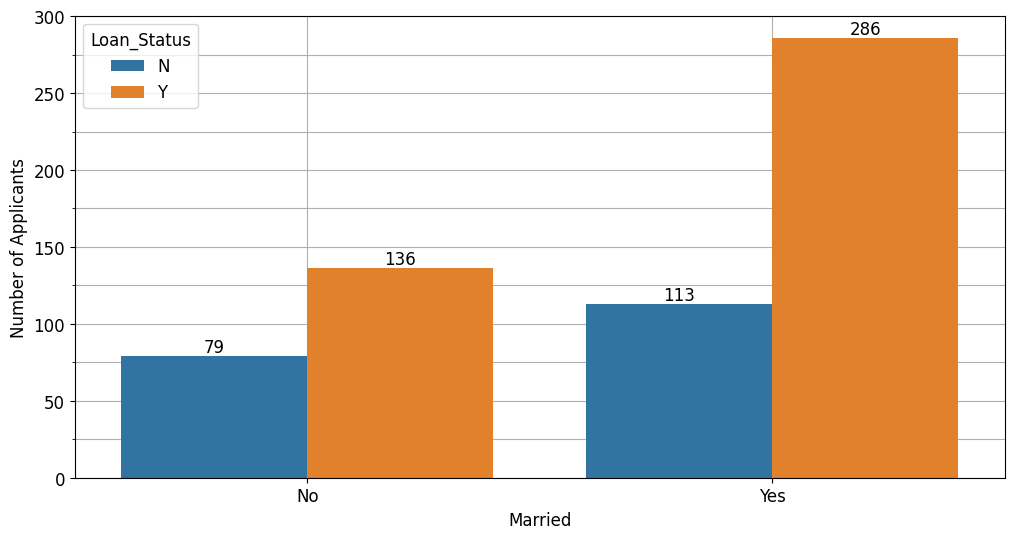

In [160]:
fig, ax = plt.subplots(figsize=(12,6))
sns.countplot(data=df, x='Married', hue='Loan_Status', ax=ax)
for container in ax.containers:
  ax.bar_label(container, label_type='edge')
# ax.set_ylim([0,200])
ax.set_ylabel('Number of Applicants')
ax.yaxis.set_minor_locator(MultipleLocator(25))
plt.grid(which='both')
ax.set_axisbelow(True)

The applicants who have married are the most acceptable loan status.

In [161]:
# Selecting only numeric data
numeric_list = df.select_dtypes(exclude=['object']).columns
numeric_list = numeric_list.delete(0)
numeric_list

Index(['Dependents', 'Applicant_Income', 'Coapplicant_Income', 'Loan_Amount',
       'Loan_Amount_Term', 'Credit_History', 'Total_Income'],
      dtype='object')

In [162]:
df_numeric = df.select_dtypes(exclude=['object'])
df_numeric.head()

,Customer_ID,Dependents,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Total_Income
0,569,0,2378,0.0,9,360,1,2378.0
1,15,2,1299,1086.0,17,120,1,2385.0
2,95,0,3620,0.0,25,120,1,3620.0
3,134,0,3459,0.0,25,120,1,3459.0
4,556,1,5468,1032.0,26,360,1,6500.0


In [163]:
df_numeric.drop('Customer_ID', axis=1, inplace=True)
df_numeric.head()

,Dependents,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Total_Income
0,0,2378,0.0,9,360,1,2378.0
1,2,1299,1086.0,17,120,1,2385.0
2,0,3620,0.0,25,120,1,3620.0
3,0,3459,0.0,25,120,1,3459.0
4,1,5468,1032.0,26,360,1,6500.0


In [164]:
df.describe()

,Customer_ID,Dependents,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Total_Income
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,307.500000,0.856678,5403.459283,1621.245798,142.022801,338.892508,0.850163,7024.705081
std,177.390811,1.216651,6109.041673,2926.248369,87.083089,69.716355,0.357203,6458.663872
min,1.000000,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000,1442.000000
25%,154.250000,0.000000,2877.500000,0.000000,98.000000,360.000000,1.000000,4166.000000
50%,307.500000,0.000000,3812.500000,1188.500000,125.000000,360.000000,1.000000,5416.500000
75%,460.750000,2.000000,5795.000000,2297.250000,164.750000,360.000000,1.000000,7521.750000
max,614.000000,4.000000,81000.000000,41667.000000,700.000000,480.000000,1.000000,81000.000000


Text(0.5, 1.0, 'Coapplicant Income')

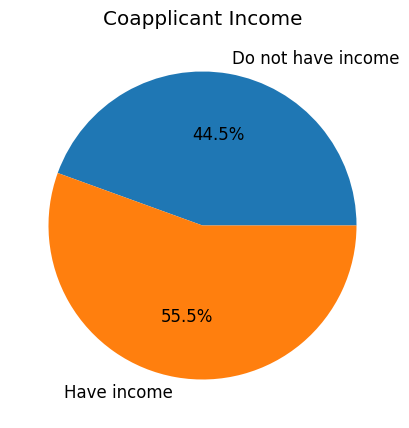

In [165]:
number_Coapplicant_Income_zero = df[df['Coapplicant_Income'] == 0].shape[0]
number_Coapplicant_Income_nonzero = df.shape[0] - number_Coapplicant_Income_zero

percentage_Coapplicant_Income_zero = (number_Coapplicant_Income_zero/df.shape[0])*100
percentage_Coapplicant_Income_nonzero = (number_Coapplicant_Income_nonzero/df.shape[0])*100

fig, ax = plt.subplots(figsize=(5,5))
ax.pie(x= [percentage_Coapplicant_Income_zero, percentage_Coapplicant_Income_nonzero],
       labels=['Do not have income', 'Have income'],
       autopct="%.1f%%");
ax.set_title('Coapplicant Income')

In [166]:
# Encoding the object data to numeric
df_object = df.select_dtypes(include=['object'])
df_object.head()

,Gender,Married,Education,Self_Employed,Property_Area,Loan_Status,Credit_History_Obj
0,Female,No,Graduate,No,Urban,N,YES
1,Male,Yes,Graduate,No,Urban,Y,YES
2,Male,No,Not Graduate,No,Semiurban,Y,YES
3,Male,Yes,Graduate,Yes,Semiurban,Y,YES
4,Male,Yes,Graduate,No,Semiurban,Y,YES


In [167]:
gender_encoder = lambda x : 1 if x == 'Male' else 0
married_encoder = lambda x : 1 if x == 'Yes' else 0
education_encoder = lambda x : 1 if x == 'Graduate' else 0
self_employed_encoder = lambda x : 1 if x == 'Yes' else 0
property_area_encoder = lambda x : 1 if x == 'Urban' else 2 if x == 'Semiurban' else 3
loan_status_encoder = lambda x : 1 if x == 'Y' else 0

mappers = [gender_encoder, married_encoder, education_encoder, self_employed_encoder, property_area_encoder, loan_status_encoder]

df_object_names = df_object.columns.to_list()
df_object_names.remove('Credit_History_Obj')
df_object_names

['Gender',
 'Married',
 'Education',
 'Self_Employed',
 'Property_Area',
 'Loan_Status']

In [168]:
df_duplicate = df.copy(deep=True)

for i, obj in enumerate(df_object_names):
  df_duplicate[obj] = df_duplicate[obj].map(mappers[i])

df_duplicate.drop(['Customer_ID','Credit_History_Obj'], axis=1, inplace=True)



In [169]:
df_duplicate.head()

,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income
0,0,0,0,1,0,2378,0.0,9,360,1,1,0,2378.0
1,1,1,2,1,0,1299,1086.0,17,120,1,1,1,2385.0
2,1,0,0,0,0,3620,0.0,25,120,1,2,1,3620.0
3,1,1,0,1,1,3459,0.0,25,120,1,2,1,3459.0
4,1,1,1,1,0,5468,1032.0,26,360,1,2,1,6500.0


## Applying Logistic Regression

In [170]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler
import numpy as np

In [171]:
target = df_duplicate['Loan_Status']
features = df_duplicate.drop('Loan_Status', axis=1)

# Splitting the dataset, the test dataset is 20% of the total dataset
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Applying the standar scaler for the scaling unbalance scale of dataset
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Applying the logistic regression
linreg_model = LogisticRegression()
linreg_model.fit(X_train_scaled,y_train)

# Predicting the test dataset (scaled)
y_pred = linreg_model.predict(X_test_scaled)

# Evaluating the accuracy of the model
print(f"Accuracy: {accuracy_score(y_pred, y_test)}")

Accuracy: 0.8211382113821138


Text(41.722222222222214, 0.5, 'Actual')

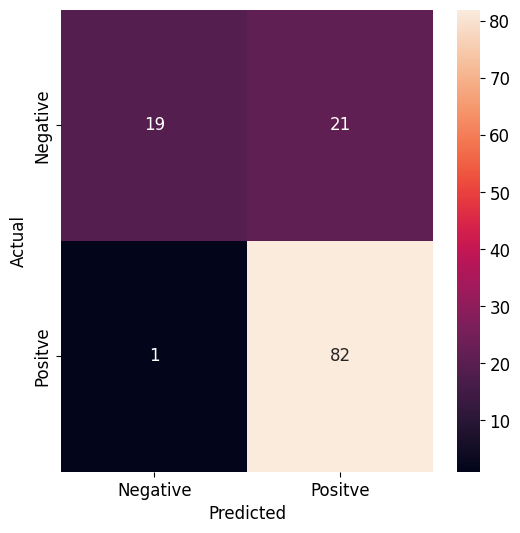

In [172]:
# Providing the confusion matrix

# true negatives is C_{0,0},
# false positives is C_{0,1},
# false negatives is C_{1,0},
# true positives is C_{1,1}

custom_x_labels = ['Negative', 'Positve']
custom_y_labels = ['Negative', 'Positve']

fig, ax = plt.subplots(figsize=(6,6))
sns.heatmap(confusion_matrix(y_test, y_pred),
            xticklabels=custom_x_labels,
            yticklabels=custom_y_labels,
            annot=True,
            ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

In [173]:
# Generating the classification report
print(classification_report(y_pred, y_test, target_names=['Loan Status-No', 'Loan Status-Yes']));

                 precision    recall  f1-score   support

 Loan Status-No       0.47      0.95      0.63        20
Loan Status-Yes       0.99      0.80      0.88       103

       accuracy                           0.82       123
      macro avg       0.73      0.87      0.76       123
   weighted avg       0.90      0.82      0.84       123



The accuracy's model has acceptable value about 82% to predict the target output. The model is suitable to predict the true target (acceptable loan status) with 80% acceptance of recall (sensitivity), but more sensitiv to predict the target of non-acceptable loan status. However, the model is able to predict with acceptable loan status with 99% precision.

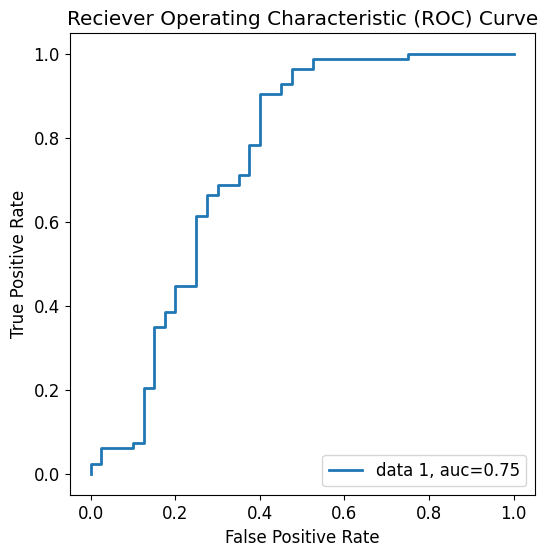

In [174]:
# Plotting the ROC curve
y_pred_proba = linreg_model.predict_proba(X_test_scaled)[::,1]
fpr, tpr, _ = roc_curve(y_test,  y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(fpr,tpr,label=f"data 1, auc={auc:.2f}")
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Reciever Operating Characteristic (ROC) Curve')
plt.legend(loc=4)
plt.show()